# Лабораторная работа №3: Понижение размерности

## Задание 1. Геометрия данных в пространстве признаков

Число: 6607 объектов, 7 признаков


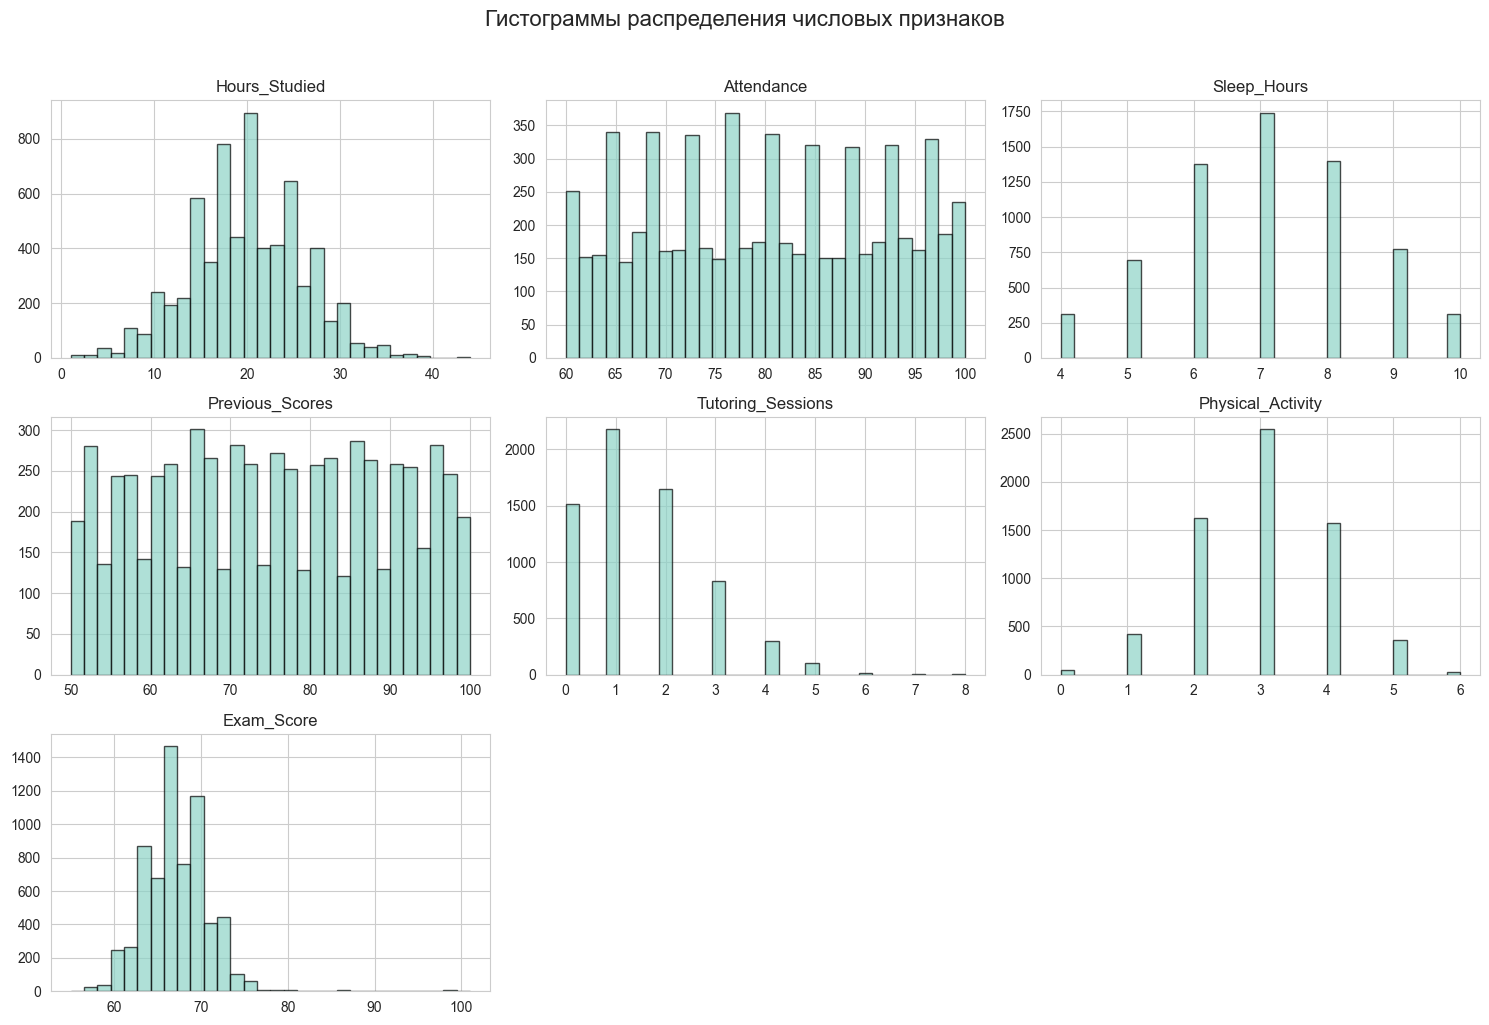

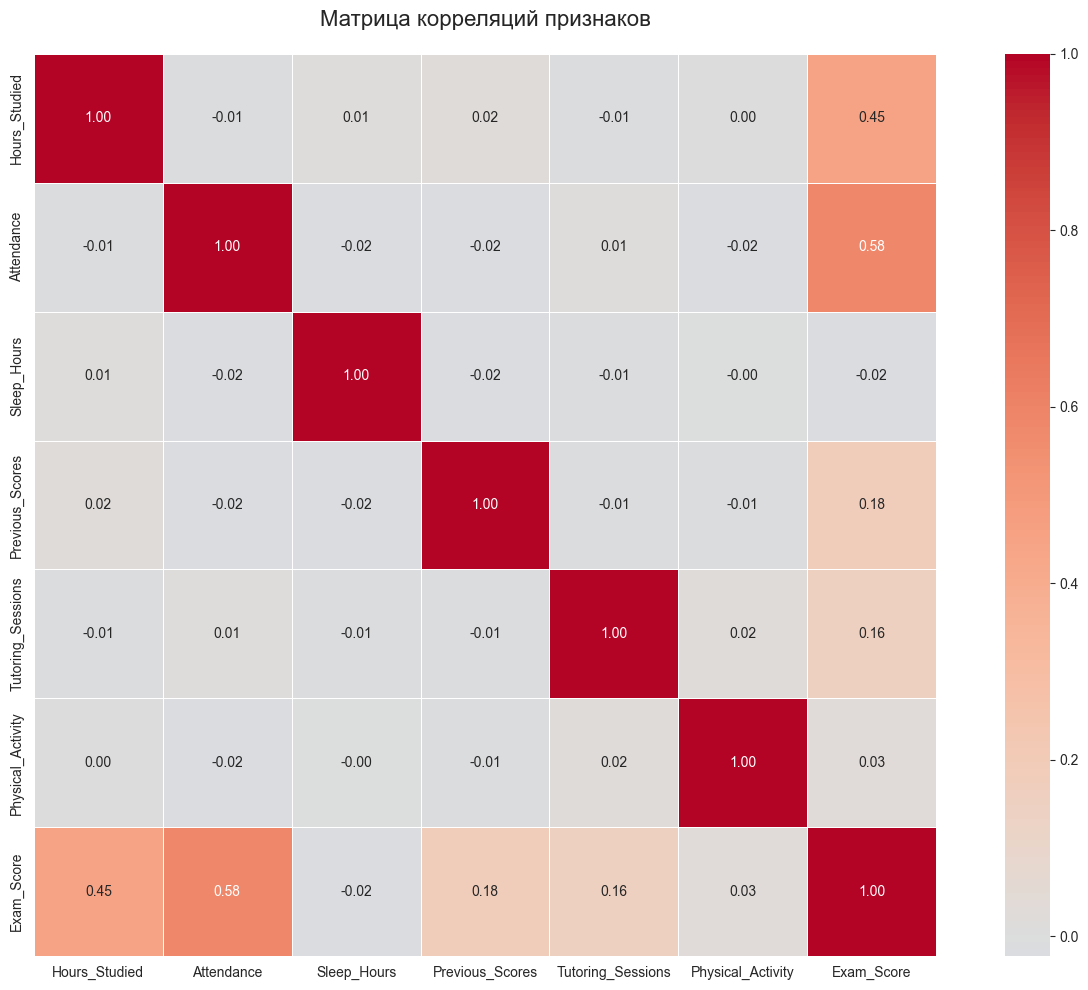

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

df = pd.read_csv('../data/StudentPerformanceFactors.csv')

df_number = df.select_dtypes(include='number')

print(f'Число: {df_number.shape[0]} объектов, {df_number.shape[1]} признаков')
df_number.head()


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]


df_number.hist(bins=30, edgecolor='black', alpha=0.7, figsize=(15, 10))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 10))
corr_matrix = df_number.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

#### Есть ли сильно коррелированные признаки?
Наиболее сильная связь наблюдается у признака Attendance (посещаемость) — корреляция 0.58. Это умеренная положительная связь: чем выше посещаемость, тем выше балл за экзамен.
Второй по силе признак — Hours_Studied (часы учебы) с корреляцией 0.45.
Все остальные значения имеют слабую связь или практически не коррелируют между собой
#### Можно ли предположить, что часть признаков содержит избыточную информацию?
Нет, все значения между признаками без целевой переменной близки к нулю

## Задание 2. Реализация PCA


--- Сравнение с sklearn ---
Наши собственные значения:      [207.95291609 138.8541781   39.25507627]
Sklearn собственные значения:   [207.95291609 138.8541781   39.25507627]


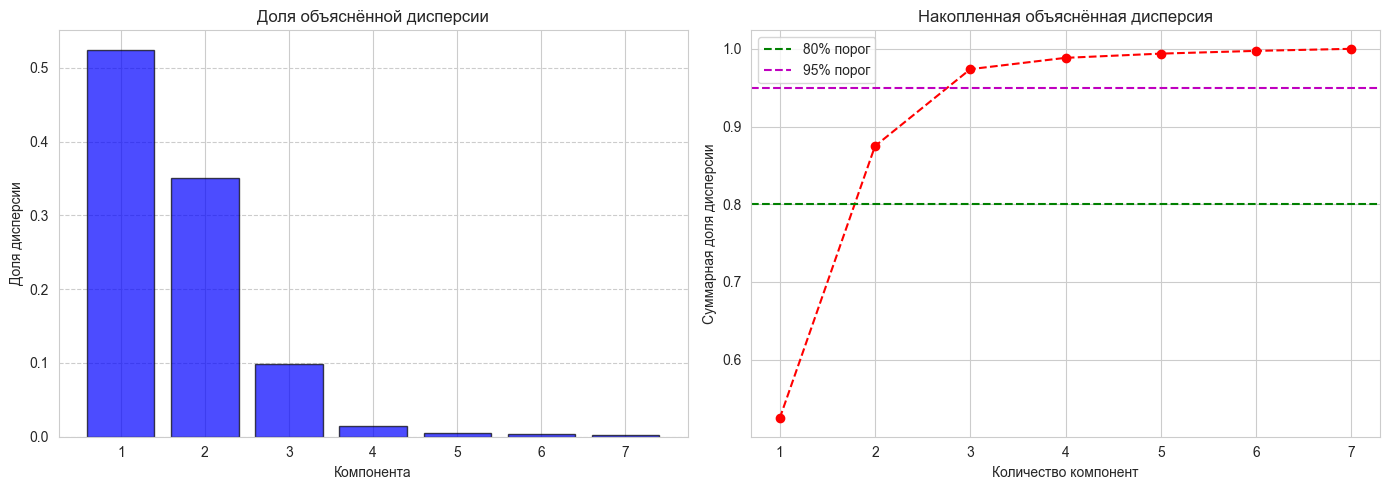


--- Ответы ---
1. Компонент для 80% дисперсии: 2
2. Компонент для 95% дисперсии: 3


In [3]:
from sklearn.decomposition import PCA as SklearnPCA

class PCAFromScratch:
    def __init__(self):
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        self.cov_matrix = np.cov(X_centered.T)

        eigenvalues, eigenvectors = np.linalg.eig(self.cov_matrix)

        sorted_indices = np.argsort(eigenvalues)[::-1]

        self.explained_variance_ = eigenvalues[sorted_indices]
        self.components_ = eigenvectors[:, sorted_indices]

        total_variance = np.sum(self.explained_variance_)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance

        return self

    def transform(self, X, k=None):

        if k is None:
            k = self.components_.shape[1]

        W = self.components_[:, :k]

        X_centered = X - self.mean_

        return np.dot(X_centered, W)

df_number = pd.read_csv('../data/StudentPerformanceFactors.csv').select_dtypes(include='number')

X = df_number.values

pca_numpy = PCAFromScratch()
pca_numpy.fit(X)

pca_sklearn = SklearnPCA()
pca_sklearn.fit(X)


print("--- Сравнение с sklearn ---")
print(f"Наши собственные значения:      {pca_numpy.explained_variance_[:3]}")
print(f"Sklearn собственные значения:   {pca_sklearn.explained_variance_[:3]}")


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_numpy.explained_variance_ratio_) + 1),
        pca_numpy.explained_variance_ratio_, alpha=0.7, color='b', edgecolor='black')
plt.title('Доля объяснённой дисперсии')
plt.xlabel('Компонента')
plt.ylabel('Доля дисперсии')
plt.xticks(range(1, len(pca_numpy.explained_variance_ratio_) + 1))
plt.grid(axis='y', linestyle='--')

plt.subplot(1, 2, 2)
cumulative_variance = np.cumsum(pca_numpy.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='r')
plt.axhline(y=0.80, color='g', linestyle='--', label='80% порог')
plt.axhline(y=0.95, color='m', linestyle='--', label='95% порог')
plt.title('Накопленная объяснённая дисперсия')
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная доля дисперсии')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


k_80 = np.argmax(cumulative_variance >= 0.80) + 1
k_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("\n--- Ответы ---")
print(f"1. Компонент для 80% дисперсии: {k_80}")
print(f"2. Компонент для 95% дисперсии: {k_95}")

## Задание 3. Интерпретация главных компонент

Коэффициенты первых 3 компонент
                     PC1    PC2    PC3
Hours_Studied      0.015 -0.015  0.947
Attendance        -0.028 -0.978 -0.080
Sleep_Hours       -0.002  0.002  0.003
Previous_Scores    0.998 -0.018 -0.032
Tutoring_Sessions -0.001 -0.003  0.003
Physical_Activity -0.001  0.002  0.002
Exam_Score         0.048 -0.209  0.309


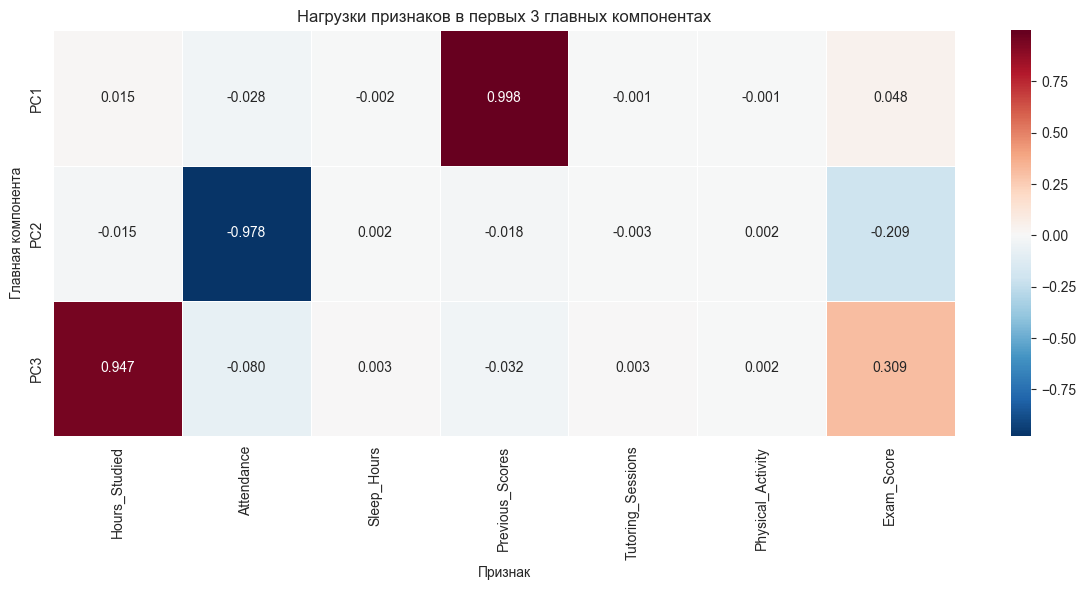

Признаки с наибольшим вкладом в каждую компоненту
PC1 (объясняет 52.5% дисперсии):
   + Previous_Scores: 0.998
   + Exam_Score: 0.048
   − Attendance: -0.028
PC2 (объясняет 35.0% дисперсии):
   − Attendance: -0.978
   − Exam_Score: -0.209
   − Previous_Scores: -0.018
PC3 (объясняет 9.9% дисперсии):
   + Hours_Studied: 0.947
   + Exam_Score: 0.309
   − Attendance: -0.080


In [4]:
feature_names = df_number.columns.tolist()

loadings = pd.DataFrame(
    pca_numpy.components_[:, :3],
    index=feature_names,
    columns=['PC1', 'PC2', 'PC3']
)

print("Коэффициенты первых 3 компонент")
print(loadings.round(3))

plt.figure(figsize=(12, 6))
sns.heatmap(loadings.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Нагрузки признаков в первых 3 главных компонентах')
plt.xlabel('Признак')
plt.ylabel('Главная компонента')
plt.tight_layout()
plt.show()


print("Признаки с наибольшим вкладом в каждую компоненту")

for i, pc in enumerate(['PC1', 'PC2', 'PC3'], 1):

    abs_loadings = loadings[pc].abs().sort_values(ascending=False)
    top_features = abs_loadings.head(3)

    print(f"{pc} (объясняет {pca_numpy.explained_variance_ratio_[i-1]*100:.1f}% дисперсии):")
    for feat, loading_abs in top_features.items():
        sign = '+' if loadings.loc[feat, pc] > 0 else '−'
        print(f"   {sign} {feat}: {loadings.loc[feat, pc]:.3f}")



#### 1. Какие признаки больше всего влияют на первую компоненту?
 Больше всего влияет Previous_Scores (0.998)
#### 2. Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?
Можно: PC1 = 0.998*Previous_Scores + 0.048*Exam_Score − 0.028*Attendance + ...
#### 3. Есть ли признаки, которые практически не влияют на первые компоненты?
Есть: Sleep_Hours(-0,002); Tutoring_Sessions(-0,001); Physical_Activity(-0,001)

## Задание 4. Визуализация данных

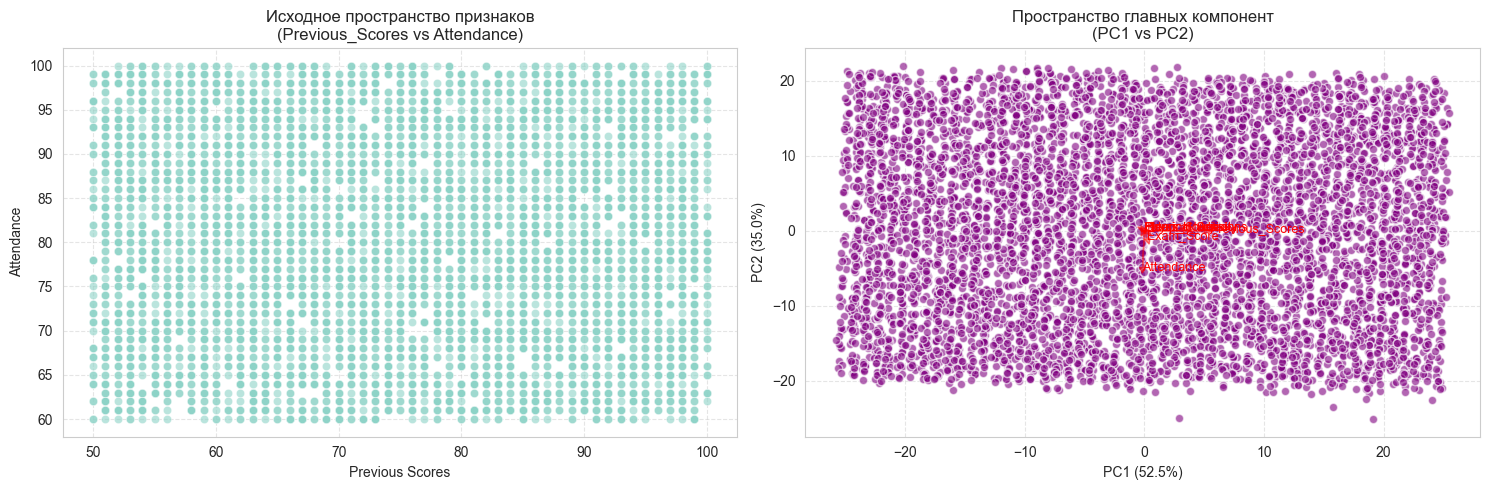

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Previous_Scores', y='Attendance', data=df_number, alpha=0.6, edgecolor='w')
plt.title('Исходное пространство признаков\n(Previous_Scores vs Attendance)')
plt.xlabel('Previous Scores')
plt.ylabel('Attendance')
plt.grid(True, linestyle='--', alpha=0.5)


X_pca = pca_numpy.transform(df_number.values, k=2)

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolor='w', c='purple')
plt.title('Пространство главных компонент\n(PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca_numpy.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_numpy.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)


scale_factor = 5
for i, feature in enumerate(df_number.columns):
    loading_x = pca_numpy.components_[i, 0] * scale_factor
    loading_y = pca_numpy.components_[i, 1] * scale_factor

    plt.arrow(0, 0, loading_x, loading_y, color='red', alpha=0.5, head_width=0.5)
    plt.text(loading_x * 1.1, loading_y * 1.1, feature, color='red', fontsize=9)

plt.tight_layout()
plt.show()

#### 1. Улучшилась ли визуализация после PCA?
Да, стало меньше шума, немного сместилась система коордиат
#### 2. Почему в пространстве главных компонент структура может быть заметнее?
Потому что она ищет новые оси по которым данные максимально расстянуты, устраняет шумы и лишние детали, приводит признаки к единому маштабу

## Задание 5. Нелинейные методы снижения размерности

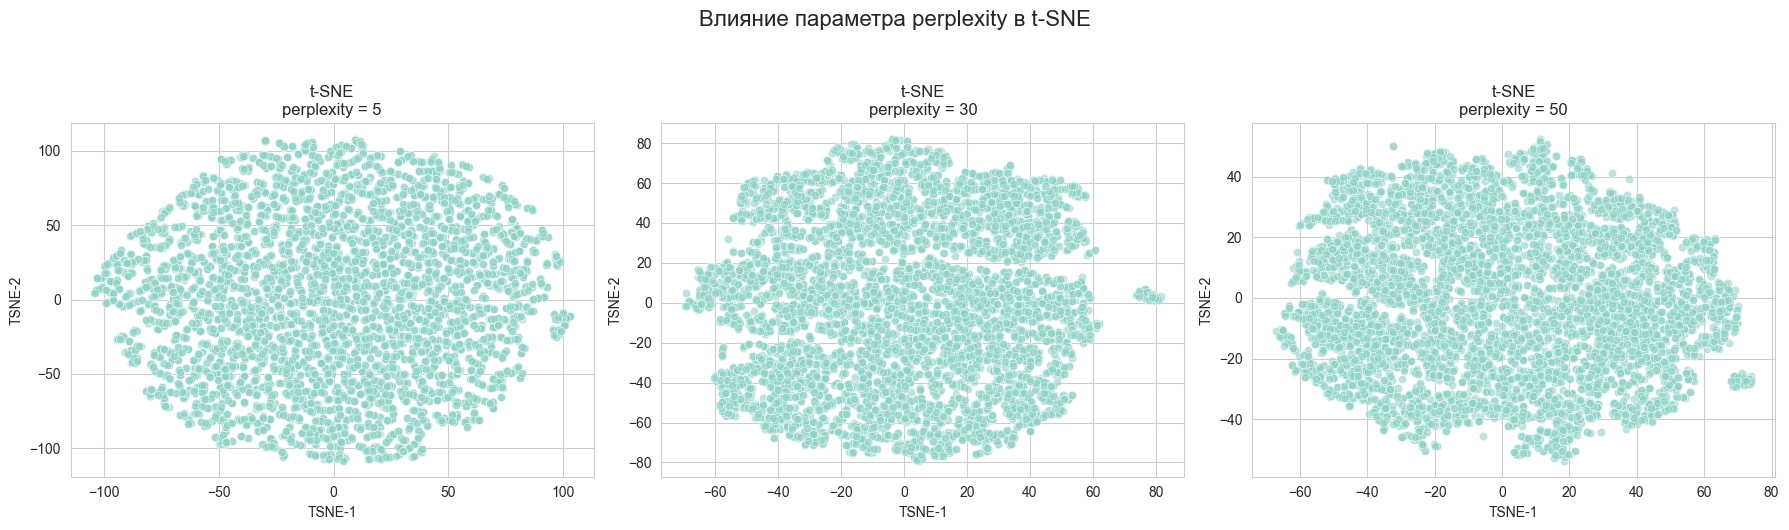

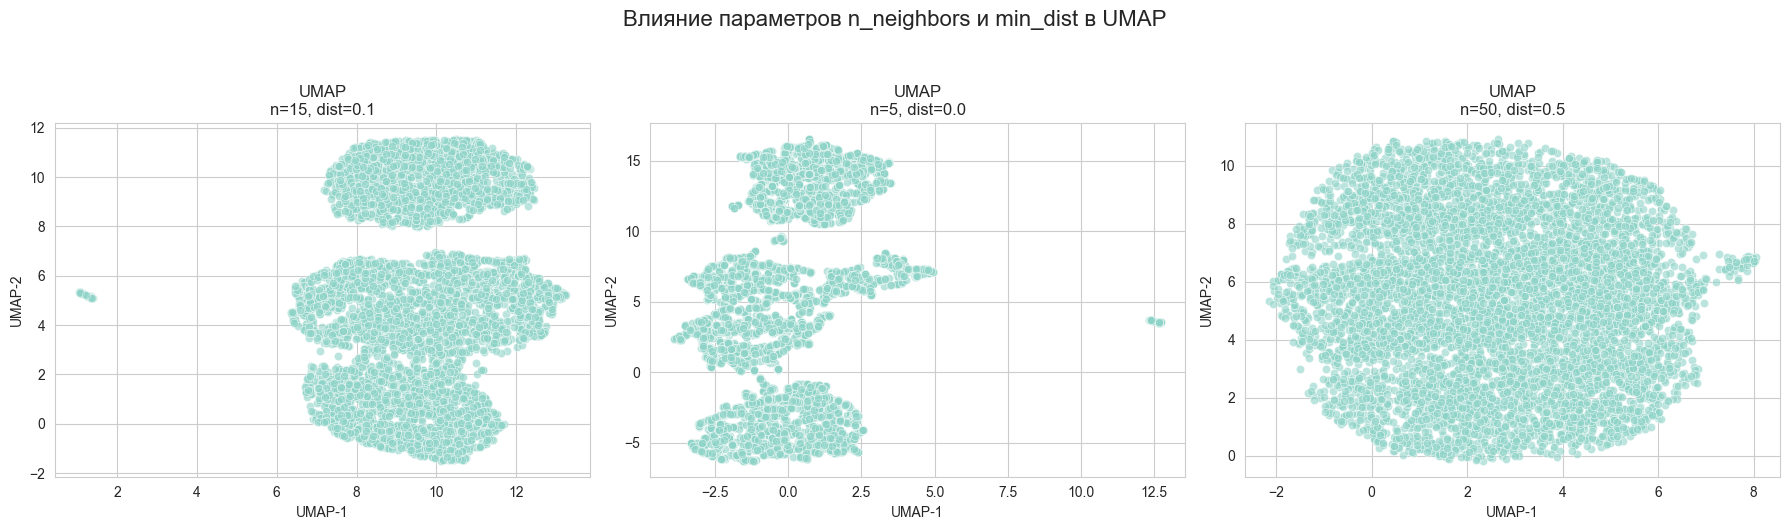

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_number)

plt.figure(figsize=(18, 5))
perplexities = [5, 30, 50]

for i, p in enumerate(perplexities):

    tsne = TSNE(n_components=2, perplexity=p, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], alpha=0.6, edgecolor='w', linewidth=0.5)
    plt.title(f't-SNE\nperplexity = {p}')
    plt.xlabel('TSNE-1')
    plt.ylabel('TSNE-2')

plt.suptitle('Влияние параметра perplexity в t-SNE', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


plt.figure(figsize=(18, 5))

configs = [
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 5, "min_dist": 0.0},
    {"n_neighbors": 50, "min_dist": 0.5}
]

for i, cfg in enumerate(configs):
    mapper = umap.UMAP(
        n_neighbors=cfg['n_neighbors'],
        min_dist=cfg['min_dist'],
        random_state=None
    )
    X_umap = mapper.fit_transform(X_scaled)

    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], alpha=0.6, edgecolor='w', linewidth=0.5)
    title = f"UMAP\nn={cfg['n_neighbors']}, dist={cfg['min_dist']}"
    plt.title(title)
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')

plt.suptitle('Влияние параметров n_neighbors и min_dist в UMAP', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

#### Как меняется структура данных при разных параметрах?
##### t-SNE:
1. perplexity = 5: Алгоритм смотрит на очень узкое окружение. Данные выглядят как рассеянное облако без четких границ.
2. perplexity = 30: Данные сжимаются более плотно.
3. perplexity = 50: Структура остается похожей на вариант с 30, но чуть более сжато.
Общий вывод: t-SNE здесь не выявил никаких внутренних групп. Данные выглядят как однородная масса. Это подтверждает выводы PCA: данные распределены достаточно равномерно.
##### UMAP:
1. n=15, dist=0.1: Данные разбиваются на две крупные группы.
2. n=5, dist=0.0: Данные разлетаются на 3 отдельных фрагментов. Это происходит потому, что min_dist=0.0 разрешает точкам прижиматься очень плотно, а малое число соседей (n=5) фокусируется на микроструктуре.
3. n=50, dist=0.5: Данные сливаются в единый большой комок. Большое число соседей заставляет алгоритм игнорировать локальные разрывы и видеть общую картину.
#### Какой метод даёт наиболее интерпретируемую визуализацию?
UMAP, так как он лучше показал, что данные не имеют естественных групп, а представляют собой непрерывное пространство, которое алгоритм искусственно разделил на фрагменты из-за параметров.
#### Почему результаты разных методов могут существенно отличаться?
Так как t-SNE использует вероятности. Он пытается сделать так, чтобы вероятность найти соседа в 2D была такой же, как в многомерном пространстве. UMAP использует теорию графов и топологию. Он строит граф соседей и пытается уложить его на плоскость, сохраняя связность.

## Задание 6. Исследование степени сжатия данных

Данные: 6607 объектов, 7 признаков
PCA: СНИЖЕНИЕ РАЗМЕРНОСТИ И ВОССТАНОВЛЕНИЕ
k= 2 | MSE=0.5979 | Дисперсия=40.21%
k= 5 | MSE=0.1680 | Дисперсия=83.20%
k= 7 | MSE=0.0000 | Дисперсия=100.00%


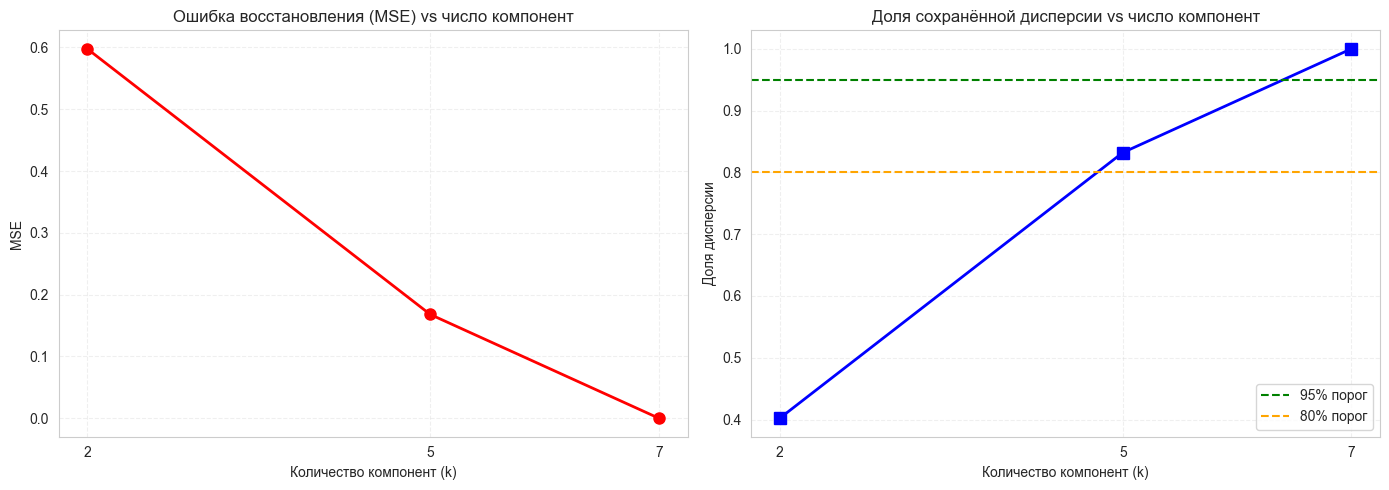

Таблица результатов:
 Число компонент (k) Ошибка восстановления (MSE) Сохранённая дисперсия (%)
                   2                      0.5979                     40.21
                   5                      0.1680                     83.20
                   7                      0.0000                    100.00

📉 Уменьшение ошибки при добавлении компонент:
  k=2 → k=5: ΔMSE = 0.4299
  k=5 → k=7: ΔMSE = 0.1680


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


df_number = df.select_dtypes(include='number')
feature_names = df_number.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_number)

n_features = X_scaled.shape[1]
n_samples = X_scaled.shape[0]
print(f"Данные: {n_samples} объектов, {n_features} признаков")

k_values = [k for k in [2, 5,7, 10, 15] if k <= n_features]
results = {}


print("PCA: СНИЖЕНИЕ РАЗМЕРНОСТИ И ВОССТАНОВЛЕНИЕ")


for k in k_values:

    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_scaled)

    X_reconstructed = pca.inverse_transform(X_reduced)

    mse = mean_squared_error(X_scaled, X_reconstructed)

    results[k] = {
        'pca': pca,
        'X_reduced': X_reduced,
        'X_reconstructed': X_reconstructed,
        'mse': mse,
        'variance_retained': np.sum(pca.explained_variance_ratio_)
    }

    print(f"k={k:2d} | MSE={mse:.4f} | Дисперсия={results[k]['variance_retained']*100:5.2f}%")


mse_values = [results[k]['mse'] for k in k_values]
variance_values = [results[k]['variance_retained'] for k in k_values]


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, mse_values, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
plt.title('Ошибка восстановления (MSE) vs число компонент')
plt.xlabel('Количество компонент (k)')
plt.ylabel('MSE')
plt.xticks(k_values)
plt.grid(True, alpha=0.3, linestyle='--')


plt.subplot(1, 2, 2)
plt.plot(k_values, variance_values, marker='s', linestyle='-', color='blue', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='green', linestyle='--', label='95% порог')
plt.axhline(y=0.80, color='orange', linestyle='--', label='80% порог')
plt.title('Доля сохранённой дисперсии vs число компонент')
plt.xlabel('Количество компонент (k)')
plt.ylabel('Доля дисперсии')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


summary_df = pd.DataFrame({
    'Число компонент (k)': k_values,
    'Ошибка восстановления (MSE)': [f"{results[k]['mse']:.4f}" for k in k_values],
    'Сохранённая дисперсия (%)': [f"{results[k]['variance_retained']*100:.2f}" for k in k_values]
})
print("Таблица результатов:")
print(summary_df.to_string(index=False))


if len(mse_values) >= 3:
    mse_diffs = np.diff(mse_values)
    print("Уменьшение ошибки при добавлении компонент:")
    for i in range(len(k_values)-1):
        print(f"  k={k_values[i]} → k={k_values[i+1]}: ΔMSE = {abs(mse_diffs[i]):.4f}")


    if len(mse_diffs) >= 2:
        diff_changes = np.diff(np.abs(mse_diffs))
        elbow_idx = np.argmax(diff_changes) + 1 if np.any(diff_changes > 0) else None
        if elbow_idx:
            print(f"Предполагаемая точка перегиба: k = {k_values[elbow_idx]}")

 #### Анализ формы графика
1.  Как быстро уменьшается ошибка?
- Происходит быстрый спад с 0.4299  до 0.1680
2. Есть ли точка, после которой уменьшение ошибки становится незначительным?
 - Нет
#### 6.5 Интерпретация результатов
1. Почему при малом числе компонент ошибка восстановления большая?
- Потому что мы отбрасываем большую часть информации о данных.
2. Почему увеличение числа компонент уменьшает ошибку?
- Каждая новая компонента добавляет недостающие детали для более точного описания данных.
3. Можно ли полностью восстановить исходные данные при использовании
всех компонент?
- Да, если число компонент равно числу исходных признаков.
4. Как это связано с объяснённой дисперсией PCA?
- Объяснённая дисперсия и ошибка восстановления (MSE) — это обратные величины
5. Как можно определить разумное число компонент, при котором данные уже
хорошо описаны, но размерность существенно меньше?
- Метод 1: Порог дисперсии — выбрать минимальное k, при котором накопленная объяснённая дисперсия ≥ 90–95%. Это стандартный.
- Метод 2: «Локоть» (Elbow) — найти на графике MSE точку, где кривая резко выполаживается: после неё добавление компонент даёт малый прирост качества.
- Метод 3: Прикладной компромисс — задать допустимый порог ошибки (например, MSE < 0.2) и выбрать наименьшее k, которое его обеспечивает.

## Задание 7. Итоговый анализ
На основе проведённых экспериментов сформулируйте выводы.
Ответьте на следующие вопросы:
1. Какую роль играет снижение размерности в анализе данных?
- Снижение размерности позволяет: визуализировать данные, умншьшать шум и избыточность, ускорять вычисления
2. Всегда ли уменьшение размерности полезно?
- Нет, это может привести к потере критичесой информации, снижению интерпритируемости
3. В каких случаях линейные методы могут работать хуже нелинейных?
- Данные работают хуже если: свернуты в спираль или сложную кривую, кластеры разделены сложными границами
4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?

| Метод | Тип | Преимущества | Ограничения |
|-------|-----|-------------|-------------|
| **PCA** | Линейный |  **Скорость**: Работает очень быстро.<br> **Интерпретируемость**: Видно вклад признаков.<br> **Обратимость**: Можно восстановить данные и оценить MSE.<br> **Глобальная структура**: Сохраняет общие расстояния. |  Только линейные зависимости.<br> Плохо разделяет сложные кластеры.<br> Чувствителен к масштабу (нужна стандартизация). |
| **t-SNE** | Нелинейный |  **Локальная структура**: Идеален для мелких кластеров.<br> **Визуализация**: Чёткое разделение групп на графике. |  **Медленный**: Сложность $O(N^2)$, плохо масштабируется.<br> **Случайность**: Результат зависит от `random_state`.<br> **Глобальная структура**: Расстояния между кластерами не информативны.<br> Нельзя применить к новым данным без пересчёта. |
| **UMAP** | Нелинейный |  **Баланс**: Сохраняет и локальную, и глобальную структуру.<br> **Скорость**: Быстрее t-SNE в 10–100 раз.<br> **Масштабируемость**: Работает с большими датасетами. |  **Параметры**: Требует подбора `n_neighbors`, `min_dist`.<br> Как и t-SNE, не позволяет восстановить исходные данные. |
